# Customer Segmentation using K-Means Clustering

## Business Objective

The objective of this project is to segment mall customers into different groups based on their purchasing behavior and demographic characteristics using K-Means Clustering. By identifying similar customer groups, businesses can better understand customer preferences and develop targeted marketing strategies to improve customer engagement and sales.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Load Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Overview

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Data Preparation

The dataset contains no missing values or duplicate records. The `Gender` column is encoded into numerical values, and the `CustomerID` column is removed since it is only an identifier and does not contribute to customer segmentation.

In [8]:
# Encode Gender column
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

# Remove CustomerID
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## Feature Scaling

Feature scaling is important for K-Means clustering because the algorithm uses Euclidean distance to form clusters. Scaling ensures that all features contribute equally to the clustering process.

In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
scaled_data[:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

## Elbow Method

The Elbow Method is used to determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS) against different values of K. The point where the curve starts to bend (forming an "elbow") indicates the optimal number of clusters.

In [11]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

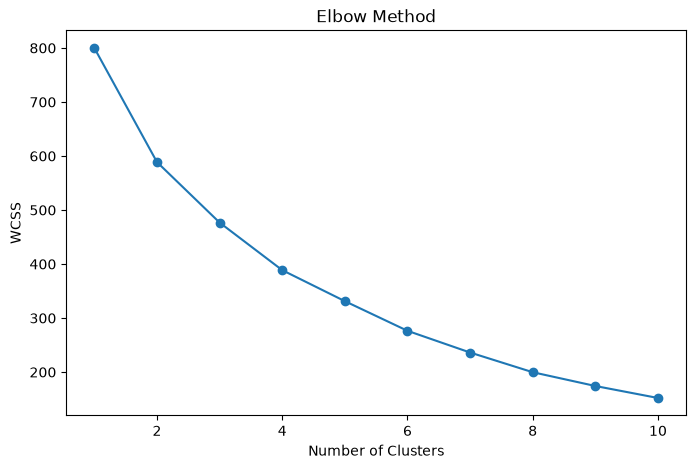

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is chosen as **5**. The K-Means algorithm is then trained, and each customer is assigned to one of the five clusters.

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


## Cluster Distribution

In [14]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

## Cluster Profiling

The average values of each feature are calculated to understand the characteristics of each customer segment.

In [15]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.461538,32.692308,86.538462,82.128205
1,0.448276,36.482759,89.517241,18.000000
2,0.000000,49.813953,49.232558,40.069767
3,0.407407,24.907407,39.722222,61.203704
4,1.000000,55.714286,53.685714,36.771429


In [16]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

In [22]:
cluster_profile.round(2)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.46,32.69,86.54,82.13
1,0.45,36.48,89.52,18.00
2,0.00,49.81,49.23,40.07
3,0.41,24.91,39.72,61.20
4,1.00,55.71,53.69,36.77


## Customer Segment Profiles

Based on the average age, annual income, and spending score, each cluster is assigned a meaningful business name to better understand customer behavior.

In [17]:
cluster_names = {
    0: "Premium Customers",
    1: "Careful High-Income Customers",
    2: "Budget-Conscious Adults",
    3: "Young Active Shoppers",
    4: "Senior Moderate Spenders"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Customer Segment"]].head()

,Cluster,Customer Segment
0,3,Young Active Shoppers
1,3,Young Active Shoppers
2,3,Young Active Shoppers
3,3,Young Active Shoppers
4,3,Young Active Shoppers


## PCA Visualization

Principal Component Analysis (PCA) is used to reduce the dataset to two dimensions, making it easier to visualize the customer clusters.

In [18]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.33690046 0.26230645]


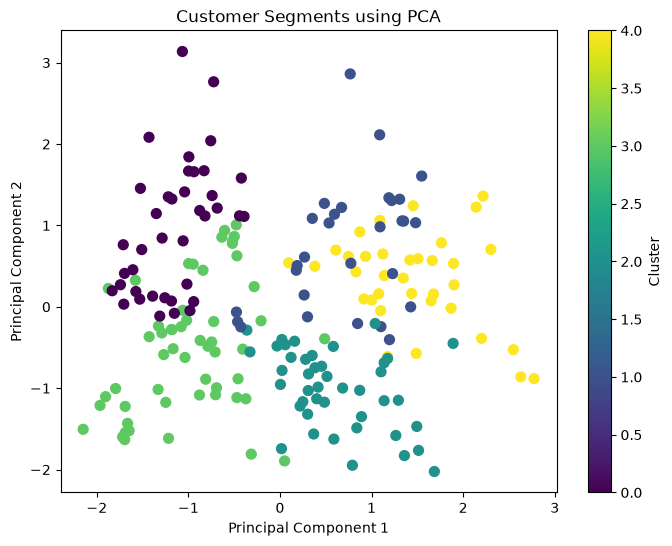

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [20]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.33690046 0.26230645]


## Business Insights

Based on the customer segments, the following observations can be made:

- **Premium Customers:** These customers have high income and high spending behavior. They are valuable customers and should be retained through exclusive offers and loyalty programs.

- **Careful High-Income Customers:** These customers earn well but spend less. Personalized promotions and premium product recommendations may encourage higher spending.

- **Budget-Conscious Adults:** These customers have moderate income and relatively low spending. Discounts and value-for-money offers can help improve engagement.

- **Young Active Shoppers:** These customers are younger and show good spending behavior despite having comparatively lower income. Trend-based marketing and seasonal offers may attract them further.

- **Senior Moderate Spenders:** These customers spend moderately and have stable purchasing behavior. Providing quality service and personalized communication can help maintain customer loyalty.

## Conclusion

This project successfully grouped customers into five meaningful segments using K-Means Clustering. The Elbow Method helped determine the optimal number of clusters, while PCA provided a clear visualization of the customer groups. The identified segments can help businesses design targeted marketing strategies, improve customer satisfaction, and make better business decisions based on customer behavior.